# 04_概率分布-均匀分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家聊的是一个非常非常简单的分布： **均匀分布** ！\~

简单来说均匀分布是一种非常基础的概率分布模型，表示某个事件在一个给定范围内发生的概率是相同的。

## 直观解释

均匀分布可以分为**离散型均匀分布**和**连续型均匀分布**。

- **离散型均匀分布**：发生的事件是有限的离散点。例如，在掷骰子时，结果只能是1到6之间的整数，每个结果出现的概率相等。
- **连续型均匀分布**：事件的可能值是无限多的，可以在某个区间内的任意点发生。例如，如果我们在0到1的区间上随机选择一个数，这个数可能是区间内的任意一个小数，并且每个数被选择的概率相同。

**本质和特点**

- **无偏性**：在均匀分布中，所有可能的结果出现的概率是一样的。比如掷骰子时，无论是1还是6，每个数字出现的概率都是1/6。
- **一致性**：均匀分布的概率分布在整个范围内都是一致的，没有任何一个区间或点具有更高或更低的概率密度。
- **区间确定性**：对于连续型均匀分布，结果必须落在指定的区间内，区间之外的概率为0。

**实际例子**

- **离散型均匀分布**：扔硬币时，正面和反面出现的概率都是50%；抽取扑克牌时，任意一张牌被抽中的概率都是一样的。
- **连续型均匀分布**：想象你在一个0到10的直线上随机选择一个点，这个点可能是5.5，也可能是7.8，在这个区间内的每一个点出现的概率是一样的。

**离散型均匀分布**

对于离散型均匀分布，可以用柱状图来展示每个可能结果出现的概率。例如，假设你掷一个六面骰子，其结果是1到6之间的整数，每个结果的概率都是1/6。

其概率质量函数（PMF）可以用如下的柱状图来表示：

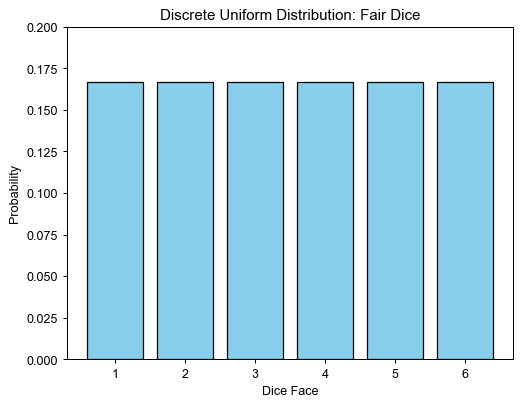

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 定义骰子面
faces = np.array([1, 2, 3, 4, 5, 6])
# 定义每个面出现的概率
probabilities = np.ones(6) / 6

# 绘制柱状图
plt.bar(faces, probabilities, color='skyblue', edgecolor='black')
plt.title('Discrete Uniform Distribution: Fair Dice')
plt.xlabel('Dice Face')
plt.ylabel('Probability')
plt.ylim(0, 0.2)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_011.png)

这张图展示了每个骰子面出现的概率都是1/6，形成了一个等高的柱状图。

**连续型均匀分布**

对于连续型均匀分布，概率密度函数（PDF）是一个常数，因为在给定区间内每个点的概率密度都是相等的。假设我们有一个均匀分布在区间 $a, b$ 上的随机变量，它的概率密度函数可以用如下的图形表示：

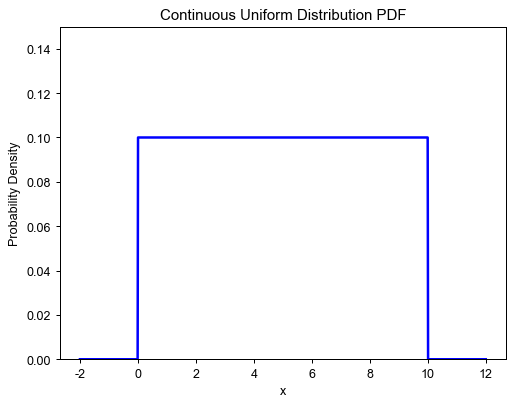

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 定义区间 [a, b]
a, b = 0, 10
x = np.linspace(a - 2, b + 2, 1000)
y = np.where((x >= a) & (x <= b), 1 / (b - a), 0)

# 绘制概率密度函数图
plt.plot(x, y, color='blue', linewidth=2)
plt.title('Continuous Uniform Distribution PDF')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.ylim(0, 0.15)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_012.png)

这张图展示了在$a, b$区间内概率密度为1/(b-a)，在区间外概率密度为0。

## 公式推导

### 离散型均匀分布

对于一个离散型均匀分布，其随机变量$X$可以取n个不同的值，每个值的概率相等为：


$$
P(X = x_i) = \frac{1}{n}, \quad \text{for } i = 1, 2, \dots, n
$$


其中，$x_i$是离散型随机变量可能取的值之一，n是这些可能值的总数。

**推导期望值和方差**

**期望值（均值）**：

期望值是随机变量的加权平均值，对于离散型均匀分布，期望值可以通过求和来计算：


$$
E[X] = \sum_{i=1}^{n} x_i \cdot P(X = x_i)
$$


对于n个可能值均匀分布的情况，期望值是：


$$
E[X] = \frac{1}{n} \sum_{i=1}^{n} x_i = \frac{1}{n} \cdot \frac{n(n+1)}{2} = \frac{n+1}{2}
$$


**方差**：

方差表示数据的离散程度，计算公式为：


$$
\text{Var}(X) = E[X^2] - (E[X])^2
$$


对于离散型均匀分布，有：


$$
E[X^2] = \frac{1}{n} \sum_{i=1}^{n} x_i^2 = \frac{1}{n} \cdot \frac{n(n+1)(2n+1)}{6}
$$


最终方差为：


$$
\text{Var}(X) = \frac{n^2 - 1}{12}
$$


### 连续型均匀分布

对于一个在区间$a, b$上的连续型均匀分布，随机变量X的概率密度函数（PDF）为：


$$
f(x) = \begin{cases}\frac{1}{b-a}, & a \leq x \leq b \\0, & \text{otherwise}\end{cases}
$$


**推导期望值和方差**

**期望值（均值）**：

对于连续型均匀分布，期望值计算为：


$$
E[X] = \int_a^b x \cdot f(x) \, dx = \int_a^b x \cdot \frac{1}{b-a} \, dx = \frac{a + b}{2}
$$


期望值为区间$a, b$的中点。

**方差**：

方差的计算过程如下：


$$
E[X^2] = \int_a^b x^2 \cdot \frac{1}{b-a} \, dx = \frac{b^3 - a^3}{3(b-a)}
$$


最终方差为：


$$
\text{Var}(X) = E[X^2] - (E[X])^2 = \frac{(b-a)^2}{12}
$$


## Python实现

**生成均匀分布的数据**

使用`numpy`库中的`np.random.uniform()`函数，可以轻松生成连续型均匀分布的数据。

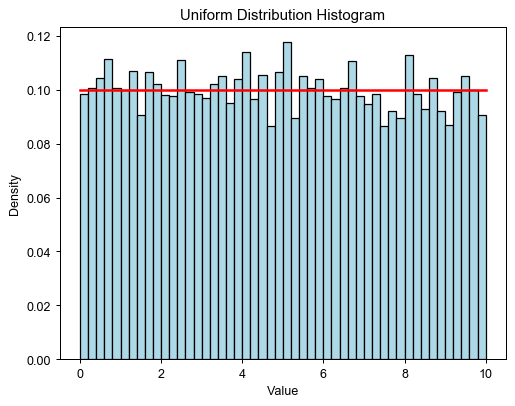

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 生成均匀分布的数据
a, b = 0, 10  # 定义区间 [a, b]
n_samples = 10000  # 生成样本数
data = np.random.uniform(a, b, n_samples)

# 绘制直方图
plt.hist(data, bins=50, density=True, edgecolor='black', color='lightblue')
plt.title('Uniform Distribution Histogram')
plt.xlabel('Value')
plt.ylabel('Density')

# 绘制理论的概率密度函数
x = np.linspace(a, b, 1000)
y = np.ones_like(x) / (b - a)
plt.plot(x, y, 'r-', lw=2)

plt.show()

![原文参考图，当前结果见代码输出](attachments/img_013.png)

**蒙特卡罗模拟估计圆周率π**

在蒙特卡罗模拟中，均匀分布常用于随机抽样，以下是用均匀分布估计π值的一个具体例子：

Estimated π after 10000 samples: 3.1568


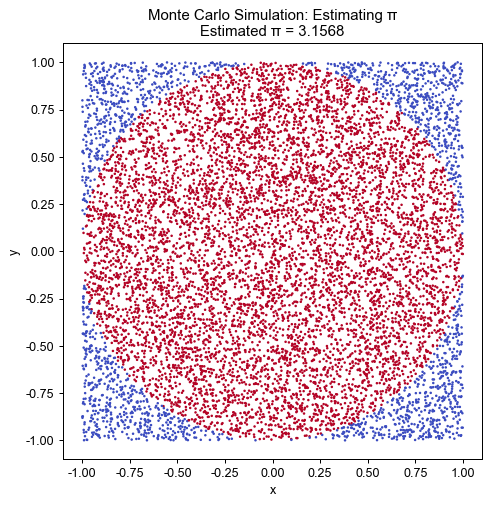

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 蒙特卡罗方法估计圆周率π
def estimate_pi(n_samples):
    inside_circle = 0


    points_x = []
    points_y = []
    for _ in range(n_samples):
        x, y = np.random.uniform(-1, 1), np.random.uniform(-1, 1)
        points_x.append(x)
        points_y.append(y)
        if x**2 + y**2 <= 1:
            inside_circle += 1
    pi_estimate = (inside_circle / n_samples) * 4
    return pi_estimate, points_x, points_y

# 估计π值
n_samples = 10000
pi_estimate, points_x, points_y = estimate_pi(n_samples)
print(f"Estimated π after {n_samples} samples: {pi_estimate}")

# 绘制模拟图
plt.figure(figsize=(6, 6))
plt.scatter(points_x, points_y, s=1, c=np.sqrt(np.array(points_x)**2 + np.array(points_y)**2) <= 1, cmap='coolwarm')
plt.title(f'Monte Carlo Simulation: Estimating π\nEstimated π = {pi_estimate}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_014.png)

在整个这个示例中，我们通过在单位正方形内生成均匀分布的点，并统计落在单位圆内的点数，最终估计出了圆周率π的值。此方法直观且展示了均匀分布在实际问题中的应用。